# Smart HVAC Energy Analytics & Predictive Maintenance System

## Phase 5 — Fault Detection Model

This notebook trains and evaluates a Random Forest classifier for binary HVAC fault detection.

The workflow includes:

- Loading the prepared training and testing datasets
- Training a baseline Random Forest model
- Evaluating classification performance
- Inspecting the confusion matrix and feature importance
- Checking for potential overfitting
- Tuning the Random Forest hyperparameters
- Comparing baseline and tuned performance
- Saving the final production model

## 1. Load Processed Dataset

The processed simulation dataset generated during the preprocessing stage is loaded as the input for feature engineering.

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Training and Testing Data

The prepared training and testing datasets generated during the feature-engineering stage are loaded.

The test dataset remains separate from training so that model performance can be evaluated on unseen data.

In [2]:
X_train = pd.read_pickle("../outputs/X_train.pkl")
X_test = pd.read_pickle("../outputs/X_test.pkl")

y_train = pd.read_pickle("../outputs/y_train.pkl")
y_test = pd.read_pickle("../outputs/y_test.pkl")

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (230305, 23)
Testing Shape  : (57577, 23)


### Verify Class Distribution

The class distribution of both datasets is verified before model training to confirm that the healthy and faulty classes are represented appropriately.

In [3]:
print("Training Class Distribution")

print(y_train.value_counts())

print()

print("Testing Class Distribution")

print(y_test.value_counts())

Training Class Distribution
health_status
1    115153
0    115152
Name: count, dtype: int64

Testing Class Distribution
health_status
0    28789
1    28788
Name: count, dtype: int64


## 3. Train Baseline Random Forest

A baseline Random Forest classifier is trained using the prepared training dataset.

The baseline model provides a reference point for evaluating the effect of later hyperparameter tuning.

In [5]:
import time

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.2f} seconds")

Training Time: 49.39 seconds


## 4. Generate Test Predictions

The trained baseline model generates:

- Class predictions for the test dataset
- Fault probabilities used for ROC-AUC evaluation

In [6]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

## 5. Baseline Model Evaluation

The baseline model is evaluated using accuracy, precision, recall, F1 score, ROC-AUC, and the classification report.

These metrics provide a broader assessment than accuracy alone, particularly for fault detection where correctly identifying faulty systems is important.

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9327


In [8]:
precision = precision_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")

Precision : 0.9742


In [9]:
recall = recall_score(y_test, y_pred)

print(f"Recall : {recall:.4f}")

Recall : 0.8889


In [10]:
f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.9296


In [11]:
roc = roc_auc_score(y_test, y_prob)

print(f"ROC AUC : {roc:.4f}")

ROC AUC : 0.9733


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     28789
           1       0.97      0.89      0.93     28788

    accuracy                           0.93     57577
   macro avg       0.94      0.93      0.93     57577
weighted avg       0.94      0.93      0.93     57577



In [15]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[28111,   678],
       [ 3198, 25590]])

## 6. Confusion Matrix

The confusion matrix shows how the baseline model classifies healthy and faulty HVAC operating conditions.

It highlights correct predictions as well as false positives and false negatives.

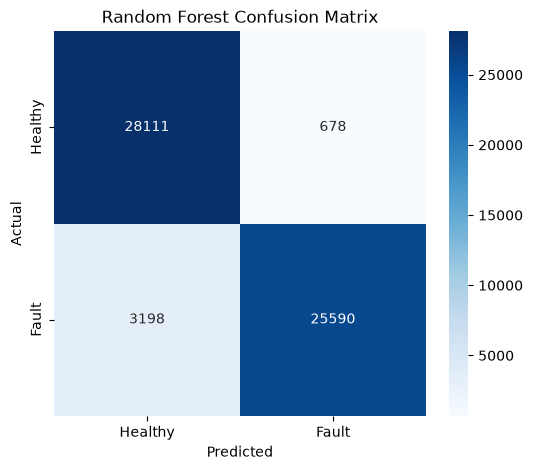

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy","Fault"],
    yticklabels=["Healthy","Fault"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

## 7. Feature Importance

Random Forest feature importance is used to identify which HVAC sensor measurements contribute most strongly to the model's classification decisions.

The top-ranked features provide insight into the physical variables most associated with fault detection.

In [18]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
1,RTU_OA_FLOW,0.167878
19,RTU_TOT_CAPA,0.068876
11,RTU_REFG_SUCT_PRES,0.065157
3,RTU_OA_TEMP,0.061870
16,RTU_SA_TEMP,0.060071
17,RTU_SEN_CAPA,0.047508
5,RTU_RA_HUM,0.043923
21,ZA_HUM,0.042311
12,RTU_REFG_SUCT_TEMP,0.041860
2,RTU_OA_HUM,0.040305


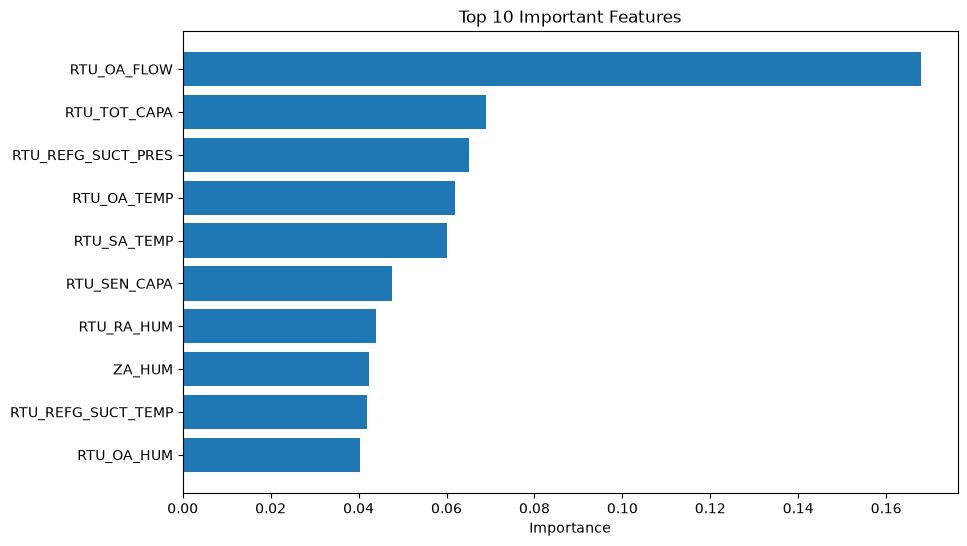

In [19]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

## 8. Overfitting Check

Training and testing accuracy are compared to identify a substantial performance gap between seen and unseen data.

A large gap may indicate that the Random Forest is overfitting the training dataset.

In [20]:
train_pred = rf_model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy : {train_accuracy:.4f}")

print(f"Testing Accuracy  : {test_accuracy:.4f}")

Training Accuracy : 1.0000
Testing Accuracy  : 0.9327


In [21]:
joblib.dump(
    rf_model,
    "../models/random_forest_fault_detector.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
print("=" * 60)
print("RANDOM FOREST MODEL SUMMARY")
print("=" * 60)

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")
print(f"Number of Features : {X_train.shape[1]}")

print()

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc:.4f}")

print()

print("Model saved to ../models/random_forest_fault_detector.pkl")

RANDOM FOREST MODEL SUMMARY
Training Samples : 230,305
Testing Samples  : 57,577
Number of Features : 23

Accuracy  : 0.9327
Precision : 0.9742
Recall    : 0.8889
F1 Score  : 0.9296
ROC AUC   : 0.9733

Model saved to ../models/random_forest_fault_detector.pkl


In [23]:
from sklearn.model_selection import RandomizedSearchCV

In [24]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

## 9. Hyperparameter Tuning

RandomizedSearchCV is used to search for a better Random Forest configuration.

The tuning process evaluates combinations of:

- Number of trees
- Maximum tree depth
- Minimum samples required for splitting
- Minimum samples per leaf
- Number of features considered at each split

F1 score is used as the optimization metric because the project focuses on reliable fault classification.

In [25]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretur

In [26]:
print("Best Parameters:")

print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


## 10. Evaluate Tuned Model

The best Random Forest identified during hyperparameter tuning is evaluated on the unseen test dataset using the same performance metrics as the baseline model.

In [27]:
best_rf = random_search.best_estimator_

best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:, 1]

best_accuracy = accuracy_score(y_test, best_pred)
best_precision = precision_score(y_test, best_pred)
best_recall = recall_score(y_test, best_pred)
best_f1 = f1_score(y_test, best_pred)
best_auc = roc_auc_score(y_test, best_prob)

## 11. Baseline vs Tuned Model

The baseline and tuned Random Forest models are compared using the same evaluation metrics.

This comparison determines whether hyperparameter tuning improved the fault detection model before selecting the production model.

In [28]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Baseline RF": [
        accuracy,
        precision,
        recall,
        f1,
        roc
    ],
    "Tuned RF": [
        best_accuracy,
        best_precision,
        best_recall,
        best_f1,
        best_auc
    ]
})

comparison

,Metric,Baseline RF,Tuned RF
0,Accuracy,0.932681,0.932074
1,Precision,0.974189,0.973361
2,Recall,0.888912,0.888460
3,F1 Score,0.929599,0.928975
4,ROC AUC,0.973278,0.972693


In [29]:
import joblib

joblib.dump(
    rf_model,
    "../models/best_fault_detector.pkl"
)

print("Production model saved successfully!")

Production model saved successfully!
